In [ ]:
!wget https://github.com/chandrikadeb7/Face-Mask-Detection/archive/refs/heads/master.zip

--2026-03-26 06:42:24--  https://github.com/chandrikadeb7/Face-Mask-Detection/archive/refs/heads/master.zip
Resolving github.com (github.com)... 20.205.243.166
Connecting to github.com (github.com)|20.205.243.166|:443... connected.
HTTP request sent, awaiting response... 302 Found
Location: https://codeload.github.com/chandrikadeb7/Face-Mask-Detection/zip/refs/heads/master [following]
--2026-03-26 06:42:25--  https://codeload.github.com/chandrikadeb7/Face-Mask-Detection/zip/refs/heads/master
Resolving codeload.github.com (codeload.github.com)... 20.205.243.165
Connecting to codeload.github.com (codeload.github.com)|20.205.243.165|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: unspecified [application/zip]
Saving to: ‘master.zip’

master.zip              [            <=>     ] 190.46M  14.4MB/s    in 13s     

2026-03-26 06:42:38 (14.9 MB/s) - ‘master.zip’ saved [199714088]



In [ ]:
import zipfile

with zipfile.ZipFile("master.zip", 'r') as zip_ref:
    zip_ref.extractall("dataset")

In [ ]:
base_path = "/content/dataset/Face-Mask-Detection-master/dataset"

In [ ]:
import os
print(os.listdir(base_path))

['with_mask', 'without_mask']


In [ ]:
import cv2
import numpy as np
import os
from tensorflow.keras.utils import to_categorical

In [ ]:
data = []
labels = []

categories = ["with_mask", "without_mask"]
img_size = 100

for category in categories:
    path = os.path.join(base_path, category)
    label = categories.index(category)

    for img in os.listdir(path)[:500]:   # limit for speed
        img_path = os.path.join(path, img)
        image = cv2.imread(img_path)

        if image is None:
            continue

        image = cv2.resize(image, (img_size, img_size))
        data.append(image)
        labels.append(label)

data = np.array(data) / 255.0
labels = to_categorical(labels)

print("Data shape:", data.shape)
print("Labels shape:", labels.shape)

Data shape: (1000, 100, 100, 3)
Labels shape: (1000, 2)


In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense

model = Sequential([
    Conv2D(32, (3,3), activation='relu', input_shape=(100,100,3)),
    MaxPooling2D(2,2),

    Conv2D(64, (3,3), activation='relu'),
    MaxPooling2D(2,2),

    Flatten(),
    Dense(64, activation='relu'),
    Dense(2, activation='softmax')
])

model.compile(optimizer='adam',
              loss='categorical_crossentropy',
              metrics=['accuracy'])

model.fit(data, labels, epochs=5, batch_size=32)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/5
32/32 ━━━━━━━━━━━━━━━━━━━━ 15s 423ms/step - accuracy: 0.7100 - loss: 0.6671
Epoch 2/5
32/32 ━━━━━━━━━━━━━━━━━━━━ 13s 421ms/step - accuracy: 0.8720 - loss: 0.3693
Epoch 3/5
32/32 ━━━━━━━━━━━━━━━━━━━━ 20s 410ms/step - accuracy: 0.8920 - loss: 0.2778
Epoch 4/5
32/32 ━━━━━━━━━━━━━━━━━━━━ 13s 406ms/step - accuracy: 0.9250 - loss: 0.1957
Epoch 5/5
32/32 ━━━━━━━━━━━━━━━━━━━━ 13s 398ms/step - accuracy: 0.9550 - loss: 0.1278


In [ ]:
model.save("mask_detector.h5")

In [ ]:
from google.colab import files
files.download("mask_detector.h5")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 367ms/step


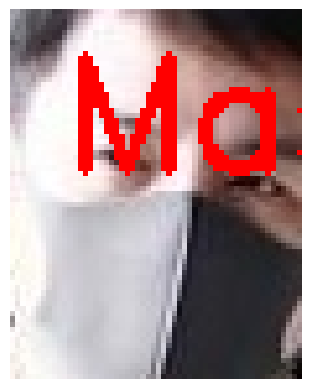

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step


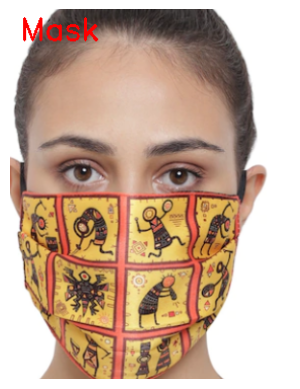

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step


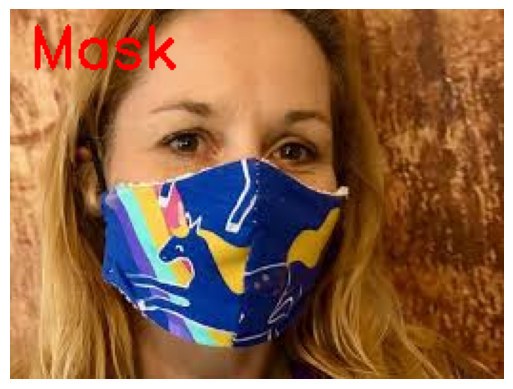

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 60ms/step


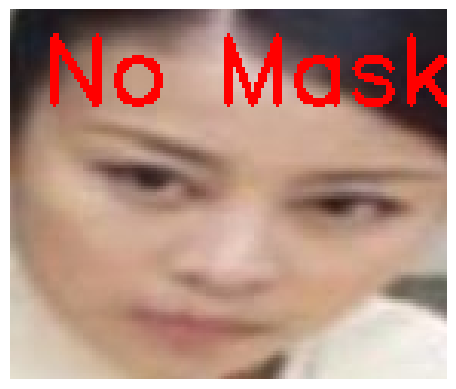

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step


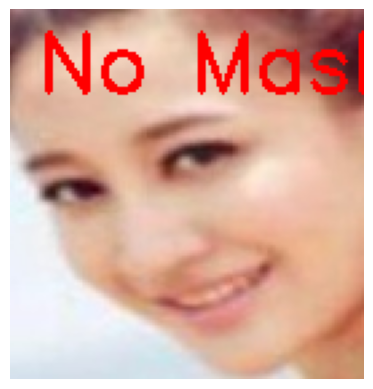

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step


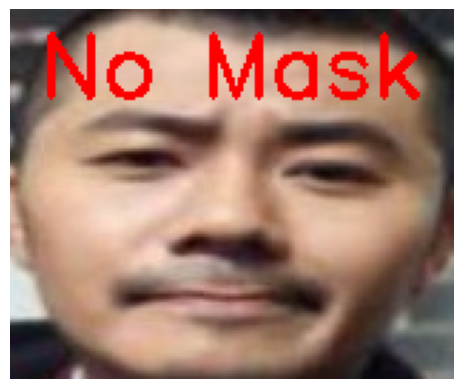

In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import os

# Model is already in memory as `model` from training

categories = ["Mask", "No Mask"]
sample_path = base_path  # this is the folder where 'with_mask' and 'without_mask' are

# Pick a few images for demo
sample_images = []
for category in ["with_mask", "without_mask"]:
    path = os.path.join(sample_path, category)
    imgs = os.listdir(path)[:3]  # pick first 3 images
    for img in imgs:
        sample_images.append(os.path.join(path, img))

# Run “detection” on each image
for img_path in sample_images:
    image = cv2.imread(img_path)
    orig = image.copy()
    image = cv2.resize(image, (100,100))
    image = np.reshape(image, (1,100,100,3))/255.0

    pred = model.predict(image)
    label = np.argmax(pred)
    text = categories[label]

    # Draw label on original image
    cv2.putText(orig, text, (10,30), cv2.FONT_HERSHEY_SIMPLEX, 1, (0,0,255), 2)

    # Convert BGR to RGB for matplotlib
    orig = cv2.cvtColor(orig, cv2.COLOR_BGR2RGB)
    plt.imshow(orig)
    plt.axis('off')
    plt.show()